# Análisis estadístico del mercado de apartamentos turísticos en Málaga y posicionamiento competitivo de una cartera propia

## Objetivo, alcance y metodología del trabajo 

El objetivo del trabajo es analizar, mediante herramientas de estadística descriptiva e inferencial, el comportamiento de la demanda de una cartera de apartamentos turísticos en Málaga y evaluar si su posicionamiento en precio y nivel de ocupación difiere significativamente del mercado local. Asimismo, se pretende estimar el impacto económico potencial de las cancelaciones y explorar posibles oportunidades de inversión por distrito dentro de la ciudad.

El análisis se estructura en torno a las siguientes preguntas:

1. ¿Cuál es el perfil estadístico de nuestra demanda?
2. ¿Siguen nuestras principales variables una distribución aproximadamente normal?
3. ¿Es el ADR medio de nuestra cartera significativamente distinto del ADR medio del mercado?
4. ¿ocupación futura respecto al mercado (Benchmark) y revenue estimado?
5. ¿Puede estimarse la pérdida esperada de revenue por cancelaciones con un 95 % de confianza?
6. ¿Existen diferencias significativas entre distritos y cuál presenta mayor potencial de ingresos?

Metodología estadística

- Estadística descriptiva (media, mediana, desviación típica, asimetría).
- Análisis gráfico (histogramas, gráficos QQ).
- Tests de normalidad (Shapiro–Wilk).
- Contrastes de hipótesis paramétricos (test t de Welch).
- Construcción de intervalos de confianza al 95 %.
- Estimación de proporciones y aplicación del Teorema Central del Límite.

Este enfoque permite no solo describir los datos observados, sino también realizar inferencias sobre la población y evaluar la significación estadística de las diferencias detectadas.

## 1. Introducción

El mercado de apartamentos turísticos en Málaga ha experimentado un crecimiento significativo en los últimos años, consolidándose como uno de los principales destinos urbanos del sur de Europa. La elevada estacionalidad, la diversidad de tipologías de alojamiento y la creciente competencia hacen necesario un análisis cuantitativo riguroso para comprender el comportamiento de la demanda y el posicionamiento competitivo.

En este contexto, el presente estudio analiza una cartera de apartamentos turísticos en Málaga y la compara con el mercado local, utilizando datos reales de reservas y un dataset de competidores obtenido mediante scraping de Airbnb en septiembre de 2025.

El análisis se desarrolla en tres bloques principales:

1. Caracterización descriptiva del mercado local.
2. Análisis estadístico de la cartera propia.
3. Análisis inferencial y contraste competitivo.

Para ello se emplean dos bases de datos:

- Un histórico de reservas de la cartera propia.
- Un dataset de mercado obtenido mediante scraping de Airbnb en septiembre de 2025, que recoge información sobre precios, capacidad, disponibilidad y localización de anuncios activos en Málaga.

Este enfoque permite no solo describir los datos observados, sino también realizar inferencias sobre el posicionamiento relativo de la cartera dentro del entorno competitivo.

### Configuración del entorno y carga de datos

En esta sección se configuran las rutas de trabajo y se cargan las dos bases de datos utilizadas en el análisis:

- `historicoreservas.csv`: histórico de reservas de la cartera propia.
- `scrapemercado.csv`: dataset de mercado obtenido mediante scraping de Airbnb.

Se define una ruta base editable para garantizar la reproducibilidad del análisis.

In [2]:
# Recursos

#%pip -q install folium

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
import os
import seaborn as sns

# CONFIGURACIÓN DE RUTA EDITABLE

BASE_PATH = r"D:\Master en Business Analytics\Estadística\Proyecto de Curso"

DATA_PATH = os.path.join(BASE_PATH, "data")

# CARGA DE DATOS

reservas = pd.read_csv(os.path.join(DATA_PATH, "historicoreservas.csv"))
competidores = pd.read_csv(os.path.join(DATA_PATH, "scrapemercado.csv"))


**2.0 Preparación del dataset de mercado**

Antes de proceder al análisis descriptivo del mercado, es necesario realizar una serie de transformaciones sobre el dataset original de competidores para garantizar la consistencia y comparabilidad de las métricas.

Las transformaciones aplicadas son las siguientes:

1. **Limpieza del precio**:  
   El precio original se encuentra en formato texto con símbolo de dólar y separadores de miles. Se convierte a formato numérico para permitir el análisis estadístico.

2. **Conversión de moneda (USD → EUR)**:  
   Dado que la cartera propia está expresada en euros, se convierte el precio del mercado a euros utilizando un tipo de cambio constante (1 USD = 0,92 EUR), con el fin de homogeneizar las unidades monetarias.

3. **Tratamiento de valores extremos**:  
   Se excluye el 1 % superior de precios (percentil 99) para reducir la influencia desproporcionada de valores atípicos extremos que distorsionan la media.

4. **Construcción de métricas derivadas**:  
   - Precio por huésped (normalización por capacidad).  
   - Ocupación futura a 60 días, estimada como:  
     \[
     Ocupación_{60} = 1 - \frac{availability_{60}}{60}
     \]

Estas transformaciones permiten trabajar con un dataset depurado y metodológicamente consistente.

In [2]:
# Limpieza del precio
competidores["price_usd"] = (
    competidores["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

competidores["price_usd"] = pd.to_numeric(
    competidores["price_usd"],
    errors="coerce"
)

# Conversión USD → EUR
tipo_cambio = 0.92
competidores["price_eur"] = competidores["price_usd"] * tipo_cambio

# Eliminación de outliers (percentil 99)
p99 = competidores["price_usd"].quantile(0.99)
competidores_filtrado = competidores[
    competidores["price_usd"] <= p99
].copy()

# Métrica ocupación 60 días
competidores_filtrado["ocupacion_60"] = 1 - (
    competidores_filtrado["availability_60"] / 60
)

resumen_mercado = pd.DataFrame({
    "Indicador": [
        "Número de anuncios",
        "Capacidad media (huéspedes)",
        "Precio medio (€)",
        "Precio mediano (€)",
        "Asimetría precio",
        "Ocupación media 60 días"
    ],
    "Valor": [
        len(competidores_filtrado),
        round(competidores_filtrado["accommodates"].mean(), 2),
        round(competidores_filtrado["price_eur"].mean(), 2),
        round(competidores_filtrado["price_eur"].median(), 2),
        round(competidores_filtrado["price_eur"].skew(), 2),
        round(competidores_filtrado["ocupacion_60"].mean(), 3)
    ]
})

resumen_mercado

,Indicador,Valor
0,Número de anuncios,8755.000
1,Capacidad media (huéspedes),3.910
2,Precio medio (€),193.350
3,Precio mediano (€),93.840
4,Asimetría precio,10.200
5,Ocupación media 60 días,0.484


## 2. Caracterización del mercado de apartamentos turísticos en Málaga

Antes de analizar la cartera propia, se realiza una descripción del mercado local a partir del dataset de competidores (anuncios activos en Airbnb en septiembre de 2025).

El objetivo de esta sección es comprender la estructura competitiva del entorno en términos de tamaño, capacidad, precios, distribución geográfica y ocupación futura.


## 2.1 Tamaño y estructura de la oferta

El dataset incluye 8.755 anuncios activos en Málaga, lo que evidencia un mercado amplio y altamente competitivo.

En términos de capacidad, los alojamientos admiten en promedio aproximadamente 4 huéspedes, concentrándose la mayor parte de la oferta en el rango de 2 a 5 personas. Esto sugiere un mercado dominado por apartamentos de pequeño y mediano tamaño, orientados principalmente a parejas y pequeños grupos.


## 2.2 Nivel y estructura de precios

Tras convertir los precios a euros y excluir el 1 % superior para reducir la influencia de valores extremos, el precio medio por noche del mercado se sitúa en torno a 193 €, mientras que la mediana es aproximadamente 94 €.

La fuerte diferencia entre media y mediana, junto con un coeficiente de asimetría elevado, indica una distribución claramente sesgada hacia la derecha. Esto refleja la coexistencia de un amplio segmento de alojamientos de precio medio con un subconjunto reducido de propiedades premium que elevan significativamente la media.

En consecuencia, el mercado presenta una estructura segmentada y heterogénea en términos de posicionamiento en precio.

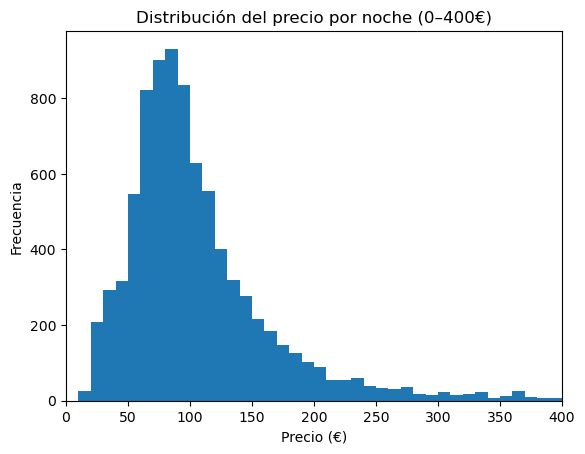

In [3]:
# Histograma Precio mercado (limitado a 0–400€ en eje X)
# Dado que la distribución presenta una cola derecha prolongada (segmento premium),
# se complementa la visualización general con un rango acotado para representar
# el comportamiento típico del mercado sin que los valores extremos distorsionen la escala.

precio = competidores_filtrado["price_eur"]
precio_400 = precio[precio <= 400]

bins = np.arange(0, 410, 10)  # intervalos de 10€

plt.figure()
plt.hist(precio_400, bins=bins)
plt.title("Distribución del precio por noche (0–400€)")
plt.xlabel("Precio (€)")
plt.ylabel("Frecuencia")
plt.xlim(0, 400)
plt.show()

La distribución confirma una fuerte concentración de anuncios en el rango comprendido aproximadamente entre 60 € y 150 € por noche, coherente con los percentiles observados anteriormente.

Se observa una cola derecha prolongada, reflejo de la existencia de un segmento premium con precios significativamente superiores a la media del mercado.

Este patrón sugiere una estructura de mercado segmentada, donde conviven alojamientos de gama media con un subconjunto reducido de propiedades de alta gama.

A continuación, se representa la localización espacial de los anuncios mediante un mapa basado en coordenadas geográficas.

Este análisis permite identificar posibles zonas de concentración de la oferta y evaluar la intensidad competitiva por área.

## 2.3 Ocupación futura a 60 días

A partir de la disponibilidad a 60 días, se estima una ocupación media cercana al 48 %, con una dispersión elevada entre alojamientos.

Este resultado sugiere que aproximadamente la mitad de la capacidad futura del mercado ya se encuentra comprometida, coexistiendo propiedades con alta ocupación y otras con disponibilidad significativa, lo que refleja un entorno competitivo dinámico.

## 2.4 Distribución geográfica de la oferta

El análisis de las coordenadas geográficas muestra una concentración significativa de anuncios en determinadas zonas urbanas, especialmente en áreas céntricas y próximas a los principales puntos de interés turístico.

La distribución espacial no es homogénea, lo que implica que la presión competitiva puede variar de forma sustancial según el distrito.

In [4]:
# LIMPIEZA DE COORDENADAS Y GENERACIÓN DEL MAPA

competidores_filtrado["latitude"] = (
    competidores_filtrado["latitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

competidores_filtrado["longitude"] = (
    competidores_filtrado["longitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

competidores_filtrado["latitude"] = pd.to_numeric(
    competidores_filtrado["latitude"],
    errors="coerce"
)

competidores_filtrado["longitude"] = pd.to_numeric(
    competidores_filtrado["longitude"],
    errors="coerce"
)

print("Coordenadas convertidas correctamente")
center = [
    competidores_filtrado["latitude"].mean(),
    competidores_filtrado["longitude"].mean()
]

m = folium.Map(location=center, zoom_start=12)

muestra = competidores_filtrado.sample(
    min(2000, len(competidores_filtrado)),
    random_state=42
)

for _, row in muestra.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=2
    ).add_to(m)

m


Coordenadas convertidas correctamente


## 2.5 Conclusiones sobre el mercado

El análisis descriptivo del mercado de apartamentos turísticos en Málaga revela un entorno altamente competitivo, con más de 8.700 anuncios activos y una estructura dominada por alojamientos de pequeño y mediano tamaño.

El mercado presenta una clara segmentación en precios, con un núcleo amplio de propiedades en el rango medio y un subconjunto reducido de alojamientos premium que generan una fuerte asimetría en la distribución.

La ocupación futura a 60 días se sitúa en torno al 48 %, lo que sugiere un nivel intermedio de presión de demanda, coexistiendo propiedades con alta ocupación y otras con disponibilidad significativa.

Finalmente, la distribución geográfica evidencia una concentración relevante de oferta en determinadas zonas urbanas, lo que implica que la intensidad competitiva varía sustancialmente según la localización.

Este contexto competitivo constituye el marco de referencia para analizar el posicionamiento de la cartera propia en las secciones siguientes.

# 3. Perfil estadístico de la demanda de la cartera propia

Una vez caracterizado el entorno competitivo, se procede a analizar el comportamiento de la demanda de la cartera propia a partir del histórico de reservas.

El objetivo de esta sección es describir estadísticamente las principales variables que determinan el rendimiento del negocio, identificar patrones de comportamiento y comprender la estructura de la demanda.

El análisis se centra en las siguientes variables clave:

- **ADR (Average Daily Rate)**: precio medio por noche.
- **Advance Booking**: número de días entre la fecha de creación de la reserva y la fecha de check-in.
- **Duración de la estancia**: número de noches por reserva.
- **Tasa de cancelación**: proporción de reservas canceladas sobre el total de reservas confirmadas.

Para cada variable se analizarán:

- Medidas de tendencia central (media y mediana).
- Medidas de dispersión (desviación típica).
- Asimetría de la distribución.
- Representación gráfica mediante histogramas.
- Probabilidades empíricas relevantes (por ejemplo, probabilidad de reserva de última hora).

Este análisis permitirá caracterizar cuantitativamente el perfil de la demanda y servirá como base para los contrastes inferenciales posteriores.

In [5]:
#Primero se muestra la información de las columnas de nuestra base de datos de reservas
reservas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4623 entries, 0 to 4622
Data columns (total 39 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   CHECK-IN                         4623 non-null   object 
 1   CHECK-OUT                        4623 non-null   object 
 2   CONFIRMATION CODE                4623 non-null   object 
 3   LISTING                          4623 non-null   object 
 4   GUEST                            4623 non-null   object 
 5   CREATION DATE                    4623 non-null   object 
 6   CONFIRMATION DATE                4623 non-null   object 
 7   CANCELLATION DATE                4623 non-null   object 
 8   GUEST'S REVIEW CREATED AT        4623 non-null   object 
 9   STAY STATUS DATE                 4623 non-null   object 
 10  CHECK-IN FORM SUBMISSION STATUS  4623 non-null   object 
 11  NUMBER OF NIGHTS                 4623 non-null   int64  
 12  PLANNED ARRIVAL     

Depuración inicial de la muestra

Antes de realizar el análisis estadístico, se procedió a depurar la base de datos original con el objetivo de trabajar únicamente con reservas efectivas.

En la variable STATUS se observó la presencia de distintos estados: confirmed, canceled, inquiry, declined, expired, closed y reserved. Sin embargo, no todos estos estados representan una reserva real que haya generado una estancia o un compromiso económico.

Las observaciones clasificadas como inquiry, declined o expired corresponden a solicitudes de información o procesos que no culminaron en una reserva confirmada. Por tanto, aunque reflejan demanda efectiva o comportamiento real de consumo, las excluiremos de este análisis, puesto que al ser una inquiry, Airbnb protege los datos personales del cliente, y además no generan datos de ADR, advance booking, ni patrón de consumidor final real.

Dado que el objetivo del estudio es analizar el comportamiento de la demanda real (precio medio por noche, lead time, cancelaciones y revenue), se decidió restringir la muestra a aquellas observaciones con estado confirmed y canceled, ya que ambas representan reservas efectivas (completadas o posteriormente anuladas).

Esta decisión metodológica permite evitar sesgos en el cálculo de métricas como ADR o tasa de cancelación y garantiza que el análisis se realice sobre unidades económicas comparables.

In [6]:
reservas["STATUS"].value_counts()

STATUS
confirmed    2568
inquiry      1118
canceled      530
declined      286
closed        110
expired        10
reserved        1
Name: count, dtype: int64

In [7]:
reservas_real = reservas[
    reservas["STATUS"].isin(["confirmed", "canceled"])
].copy()

reservas_real["STATUS"].value_counts()

STATUS
confirmed    2568
canceled      530
Name: count, dtype: int64

La muestra final utilizada para el análisis está compuesta por 3.098 reservas efectivas, de las cuales 2.568 fueron completadas y 530 canceladas. Esta depuración permite centrar el análisis en demanda real, evitando distorsiones derivadas de inquiries o solicitudes no materializadas.


#### Revisión preliminar del ADR y detección de valores atípicos

Con el objetivo de analizar el posicionamiento en precio de la cartera, se calcula el Average Daily Rate (ADR), definido como el ingreso medio generado por noche de estancia.

El ADR constituye una de las principales métricas del sector turístico, ya que permite comparar estructuras de precios independientemente de la duración de la reserva.

Matemáticamente, se define como:

**ADR = Ingreso total de la reserva / Número de noches**

En el presente estudio, el ingreso total se corresponde con la variable TOTAL PAID, mientras que la duración de la estancia viene dada por NUMBER OF NIGHTS.
El análisis descriptivo inicial del ADR revela la presencia de valores negativos y observaciones con valor cero. Desde un punto de vista económico, un precio medio por noche negativo carece de interpretación válida, por lo que estos casos probablemente corresponden a reembolsos, ajustes contables o cancelaciones con devolución total.

Asimismo, los valores iguales a cero reflejan reservas que no generaron ingreso efectivo. La inclusión de estos valores distorsiona las medidas de tendencia central, especialmente la media, y aumenta artificialmente la dispersión. Por tanto, antes de proceder con el análisis inferencial, resulta necesario depurar la variable para centrarse en reservas con ingreso positivo efectivo.

Se observa que 1.123 observaciones presentan un ADR igual a cero, lo que representa aproximadamente el 36 % de la muestra de reservas efectivas. Estos casos corresponden, previsiblemente, a reservas canceladas con reembolso completo o situaciones sin generación de ingreso efectivo.

Dado que el objetivo del estudio es analizar el posicionamiento en precio y la estructura de la demanda real, la inclusión de valores nulos distorsionaría las medidas de tendencia central y dispersión, especialmente la media y la desviación típica.

Por tanto, para el análisis específico del ADR como variable de precio, se restringe la muestra a aquellas reservas con ingreso positivo.

In [8]:
reservas_real["ADR"] = reservas_real["TOTAL PAID"] / reservas_real["NUMBER OF NIGHTS"]
reservas_real["ADR"].describe()

count    3098.000000
mean       95.746312
std       122.813566
min       -87.400000
25%         0.000000
50%        64.386667
75%       139.594018
max      1365.716667
Name: ADR, dtype: float64

In [9]:
(reservas_real["ADR"] <= 0).sum()
reservas_real["ADR"].value_counts().head(10)

ADR
0.000000      1123
67.575000        7
66.300000        6
96.050000        5
137.700000       5
57.233333        4
59.783333        4
195.925000       4
93.500000        4
68.425000        4
Name: count, dtype: int64

In [10]:
reservas_precio = reservas_real[reservas_real["ADR"] > 0].copy()

reservas_precio["ADR"].describe()

count    1970.000000
mean      150.702600
std       124.161361
min         0.003333
25%        71.182500
50%       116.610000
75%       187.962500
max      1365.716667
Name: ADR, dtype: float64

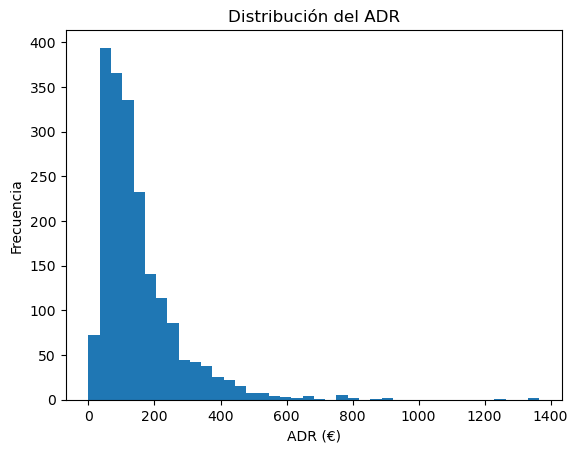

In [11]:
plt.hist(reservas_precio["ADR"], bins=40)
plt.title("Distribución del ADR")
plt.xlabel("ADR (€)")
plt.ylabel("Frecuencia")
plt.show()

Tras restringir la muestra a reservas con ingreso positivo, el ADR medio se sitúa en 150,70 €, mientras que la mediana alcanza los 116,61 €. La diferencia entre ambas medidas sugiere la presencia de asimetría positiva en la distribución, consecuencia de reservas con precios significativamente superiores al promedio.

La desviación típica (124,16 €) revela una elevada dispersión en los precios por noche, lo que indica heterogeneidad en el posicionamiento de la cartera. Este resultado es coherente con la posible coexistencia de distintos segmentos de producto (estándar y premium).

El amplio rango observado, con valores máximos que superan ampliamente la media, refuerza la hipótesis de una distribución no simétrica.
    

#### Advance Booking

Simboliza la antelación con la que los clientes realizan la reserva, técnicamente se conoce como Lead Time es sumamente importante a la hora de establecer estrategias de pricing. Conocer tu ventana de oportunidad y compararla con años anteriores te permite ajustar tu precio con antelación y realizar benchmarking si fuese necesario.

In [12]:
reservas_real["CHECK-IN"] = pd.to_datetime(
    reservas_real["CHECK-IN"],
    errors="coerce"
)

C:\Users\jassa\AppData\Local\Temp\ipykernel_5244\3248645847.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  reservas_real["CHECK-IN"] = pd.to_datetime(


In [13]:
reservas_real["CREATION DATE"] = pd.to_datetime(
    reservas_real["CREATION DATE"],
    errors="coerce"
)

C:\Users\jassa\AppData\Local\Temp\ipykernel_5244\381797007.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  reservas_real["CREATION DATE"] = pd.to_datetime(


In [14]:
reservas_real["LEAD_TIME"] = (
    reservas_real["CHECK-IN"] - reservas_real["CREATION DATE"]
).dt.days
reservas_real["LEAD_TIME"].describe()

count    3098.000000
mean       30.648483
std        43.848693
min       -66.000000
25%         5.000000
50%        16.000000
75%        41.000000
max       480.000000
Name: LEAD_TIME, dtype: float64

El análisis preliminar del lead time revela la existencia de valores negativos, lo que implica que la fecha de creación de la reserva es posterior a la fecha de entrada. Desde el punto de vista del comportamiento de la demanda, estos casos no son interpretables como decisiones reales de planificación, sino que probablemente responden a modificaciones administrativas o ajustes en el sistema.

Con el fin de evitar distorsiones en las medidas descriptivas, se procede a restringir el análisis a observaciones con lead time no negativo.

In [15]:
(reservas_real["LEAD_TIME"] < 0).sum()

np.int64(43)

Se identificaron 43 observaciones (aproximadamente el 1,4 % de la muestra) con lead time negativo. Dado que esta situación implica que la reserva fue creada con posterioridad a la fecha de entrada, se considera que estos casos responden a ajustes administrativos o inconsistencias en el registro de datos.

Dado su carácter no representativo del comportamiento real de planificación del cliente, estas observaciones se excluyen del análisis temporal.

In [16]:
reservas_real = reservas_real[reservas_real["LEAD_TIME"] >= 0].copy()

reservas_real["LEAD_TIME"].describe()

count    3055.000000
mean       31.283797
std        43.762018
min         0.000000
25%         5.000000
50%        16.000000
75%        41.000000
max       480.000000
Name: LEAD_TIME, dtype: float64

Tras depurar valores inconsistentes, el lead time medio se sitúa en 31,3 días, mientras que la mediana es de 16 días. La diferencia entre ambas medidas indica una distribución asimétrica positiva, caracterizada por una mayoría de reservas realizadas con escasa antelación y un subconjunto reducido de reservas con planificación muy anticipada.

El 25 % de las reservas se realiza con menos de 5 días de antelación, lo que sugiere una presencia significativa de demanda de última hora. La elevada desviación típica (43,8 días) refleja una considerable dispersión en los patrones de planificación.

Además es sorprendente el altísimo ratio de reservas "Ninja" de última hora. Conocer el comportamiento del consumidor es esencial para maximizar el revenue recibido por reservas de última hora. Nuestra muestra demuestra que, tener un pricing adecuado en el corto plazo, permite captar muchísima demanda urbana; Escapadas de fin de semana, decisiones de última hora, turismo doméstico, personas que esperan bajadas de precio, etc.

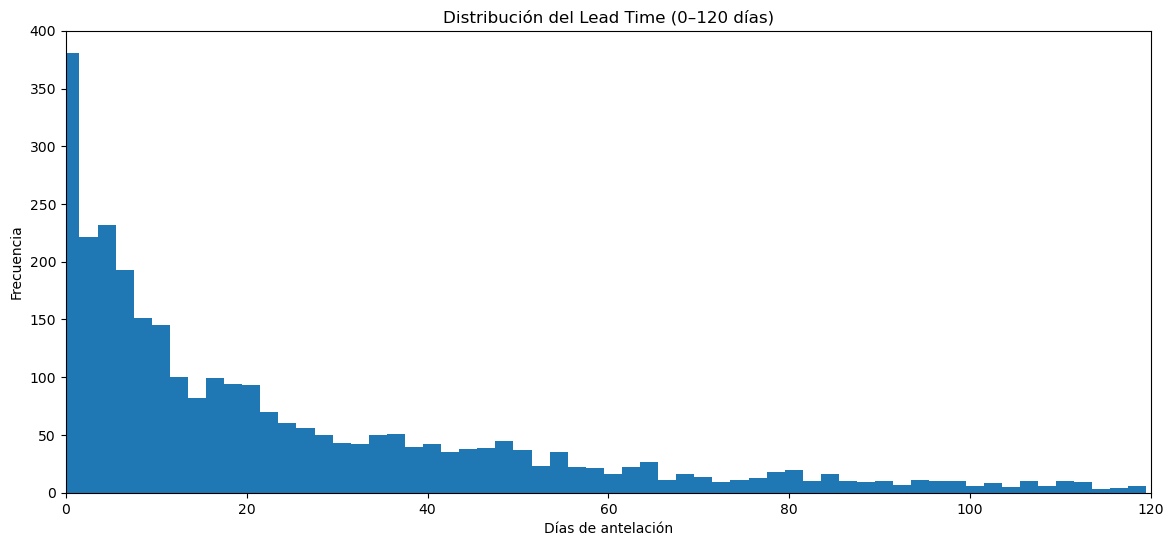

In [17]:
# Histograma Lead Time (limitado a 0–120 días)
# Se acota el eje X para representar el comportamiento central
# sin que los valores extremos deformen la escala.

lead = reservas_real["LEAD_TIME"]
lead_120 = lead[(lead >= 0) & (lead <= 120)]

bins = np.arange(-0.5, 120.5 + 1, 2)

plt.figure(figsize=(14,6))
plt.hist(lead_120, bins=bins)
plt.title("Distribución del Lead Time (0–120 días)")
plt.xlabel("Días de antelación")
plt.ylabel("Frecuencia")
plt.xlim(0, 120)
plt.show()

In [18]:
prob_last_minute = (reservas_real["LEAD_TIME"] < 2).mean()
prob_last_minute

np.float64(0.12471358428805238)

Se estima la probabilidad empírica de que una reserva se realice con menos de 7 días de antelación mediante la proporción muestral correspondiente. El resultado obtenido es del 12.5 %, lo que indica que aproximadamente una de cada seis reservas presentan un comportamiento de última hora.

Este resultado evidencia la relevancia del segmento “last minute” en la cartera analizada y sugiere la necesidad de estrategias de revenue management adaptadas a ventanas temporales cortas.

#### Tasa de cancelación

Se define la tasa de cancelación como la proporción de reservas canceladas sobre el total de reservas efectivas. La estimación puntual obtenida es del 17,15 %, lo que indica que aproximadamente una de cada seis reservas no llega a materializarse.

Este resultado tiene implicaciones relevantes para la gestión del revenue y la planificación operativa, ya que introduce incertidumbre en la ocupación final y en los ingresos previstos.

In [19]:
# Variable binaria de cancelación
reservas_real["CANCELADA"] = (reservas_real["STATUS"] == "canceled").astype(int)

# Tasa de cancelación
tasa_cancelacion = reservas_real["CANCELADA"].mean()

tasa_cancelacion

np.float64(0.17152209492635023)

#### Duración de la estancia

In [20]:
dur = reservas_real["NUMBER OF NIGHTS"]
dur_30 = dur[dur <= 30]
dur.describe()

count    3055.000000
mean        5.185270
std         6.988557
min         1.000000
25%         3.000000
50%         4.000000
75%         6.000000
max       299.000000
Name: NUMBER OF NIGHTS, dtype: float64

In [21]:
prob_2_noches = (dur == 2).mean()
prob_3_noches = (dur == 3).mean()
prob_7_o_mas = (dur >= 7).mean()

prob_2_noches, prob_3_noches, prob_7_o_mas

(np.float64(0.15973813420621932),
 np.float64(0.18657937806873978),
 np.float64(0.23142389525368248))

La duración media de la estancia en la cartera analizada es de **5,19 noches**, mientras que la mediana se sitúa en **4 noches**. La diferencia entre ambas medidas indica la presencia de una ligera asimetría positiva, provocada por un número reducido de estancias largas que elevan la media.

El percentil 25 se sitúa en 3 noches y el percentil 75 en 6 noches, lo que implica que el 50 % central de las reservas se concentra entre 3 y 6 noches. Esto confirma que el perfil predominante corresponde a estancias cortas o medias, típicas de turismo urbano y escapadas de fin de semana ampliadas.

La desviación típica (6,99 noches) es relativamente elevada en comparación con la media, debido a la existencia de valores extremos —con estancias máximas de hasta 299 noches— que generan una cola derecha prolongada en la distribución.

Desde el punto de vista probabilístico:

- El **15,97 %** de las reservas corresponden a estancias de 2 noches.
- El **18,66 %** son de 3 noches.
- El **23,14 %** superan las 7 noches.

Estos resultados evidencian que, aunque el núcleo principal de la demanda se concentra en estancias cortas (2–4 noches), existe también un segmento significativo de estancias más largas que contribuye de forma relevante a la ocupación total.

En conjunto, la estructura observada es coherente con un destino urbano de alta rotación, caracterizado por escapadas cortas combinadas con un componente minoritario de estancias prolongadas.

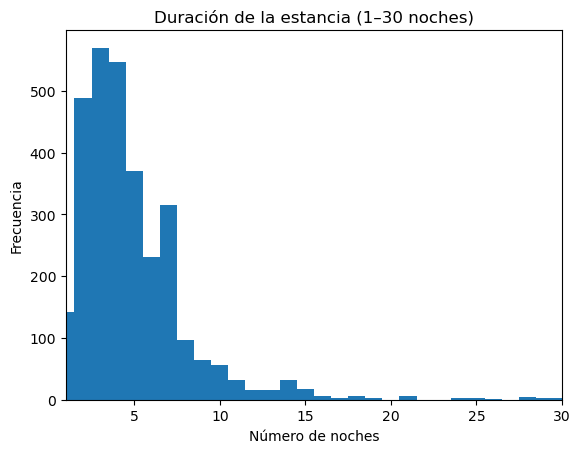

In [22]:
bins = np.arange(0.5, 30.5 + 1, 1)  # bordes para enteros (1 noche, 2 noches...)

plt.figure()
plt.hist(dur_30, bins=bins)
plt.title("Duración de la estancia (1–30 noches)")
plt.xlabel("Número de noches")
plt.ylabel("Frecuencia")
plt.xlim(1, 30)
plt.show()

# 2. Análisis de Normalidad de las Variables Principales

En esta sección se analiza si las principales variables cuantitativas del estudio (ADR, Lead Time y Duración de la estancia) siguen una distribución aproximadamente normal.

La evaluación se realizará mediante:

- Representación gráfica (histogramas y gráficos QQ).
- Test formal de normalidad de Shapiro–Wilk.
- Interpretación del valor p con un nivel de significación del 5 %.

El objetivo es determinar si se cumplen los supuestos necesarios para la aplicación de contrastes paramétricos en los apartados posteriores.

In [23]:
from scipy.stats import shapiro

stat, p_value = shapiro(reservas_precio["ADR"].sample(500, random_state=42))

stat, p_value

(np.float64(0.7691449156648495), np.float64(6.436534706680095e-26))

### 2.1 Test de normalidad para el ADR

Se aplicó el test de Shapiro–Wilk sobre una muestra aleatoria de 500 observaciones del ADR. El estadístico obtenido fue 
𝑊 = 0, 7501

W=0,7501, con un p-valor inferior a 0,001.

Dado que el p-valor es significativamente menor que el nivel de significación del 5 %, se rechaza la hipótesis nula de normalidad. Por tanto, puede concluirse que la distribución del ADR no es compatible con una distribución normal.

Este resultado es coherente con la elevada asimetría observada en el análisis descriptivo previo.

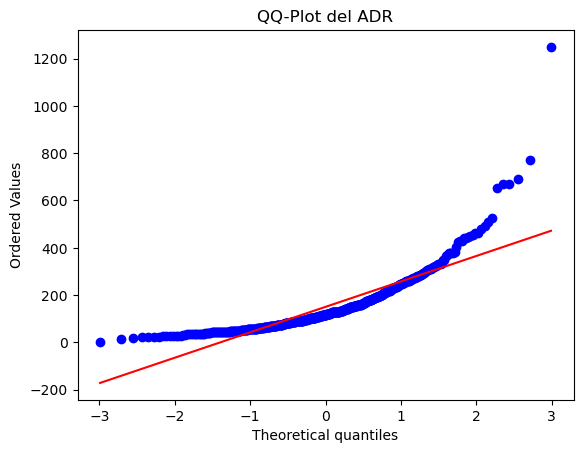

In [24]:
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure()
stats.probplot(reservas_precio["ADR"].sample(500, random_state=42), dist="norm", plot=plt)
plt.title("QQ-Plot del ADR")
plt.show()

El gráfico QQ revela que los cuantiles empíricos del ADR se desvían notablemente de la recta teórica de normalidad, especialmente en los extremos superiores. Esta desviación sistemática indica la presencia de cola derecha pesada y valores extremos elevados.

La falta de alineación en los extremos confirma visualmente el resultado del test de Shapiro–Wilk, reforzando la conclusión de que el ADR no sigue una distribución normal.

### 2.2 Normalidad del Lead Time

Se analiza si la variable *Lead Time* sigue una distribución aproximadamente normal mediante el test de Shapiro–Wilk y su representación gráfica mediante QQ-plot.

In [25]:
from scipy.stats import shapiro

stat_lt, p_value_lt = shapiro(reservas_real["LEAD_TIME"].sample(500, random_state=42))

stat_lt, p_value_lt

(np.float64(0.6617220824775716), np.float64(2.6081575305732436e-30))

El test de Shapiro–Wilk aplicado a una muestra aleatoria de 500 observaciones del Lead Time arroja un estadístico 
𝑊 = 0,6617
W=0,6617 y un p-valor inferior a 0,001.

Dado que el p-valor es significativamente menor que el nivel de significación del 5 %, se rechaza la hipótesis nula de normalidad. Por tanto, la distribución del Lead Time no puede considerarse normal.

Este resultado es coherente con la asimetría positiva observada en el análisis descriptivo previo y con la presencia de una cola derecha prolongada.

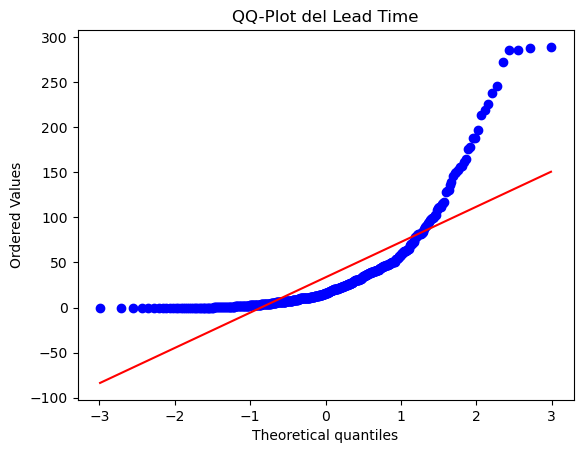

In [26]:
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure()
stats.probplot(reservas_real["LEAD_TIME"].sample(500, random_state=42), dist="norm", plot=plt)
plt.title("QQ-Plot del Lead Time")
plt.show()

El QQ-plot del Lead Time muestra una desviación clara respecto a la recta teórica de normalidad, especialmente en la cola derecha. La curvatura pronunciada y la separación creciente de los puntos en los cuantiles superiores indican la presencia de una cola pesada y una marcada asimetría positiva.

Este comportamiento confirma visualmente los resultados del test de Shapiro–Wilk y refuerza la conclusión de que la variable Lead Time no sigue una distribución normal.

### 2.3 Normalidad de la Duración de la Estancia

Se analiza la normalidad de la variable *Duración de la estancia* mediante el test de Shapiro–Wilk y su representación gráfica mediante QQ-plot.

In [27]:
from scipy.stats import shapiro

stat_dur, p_value_dur = shapiro(reservas_real["NUMBER OF NIGHTS"].sample(500, random_state=42))

stat_dur, p_value_dur

(np.float64(0.5883034932049571), np.float64(1.0395212227568117e-32))

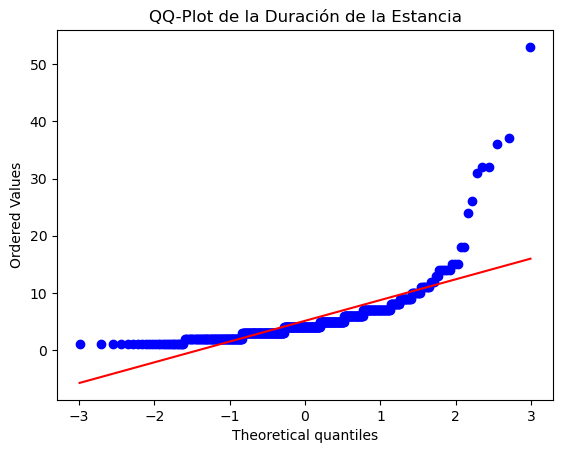

In [28]:
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure()
stats.probplot(reservas_real["NUMBER OF NIGHTS"].sample(500, random_state=42), dist="norm", plot=plt)
plt.title("QQ-Plot de la Duración de la Estancia")
plt.show()

Los resultados obtenidos mediante el test de Shapiro–Wilk y los gráficos QQ permiten concluir que ninguna de las principales variables cuantitativas (ADR, Lead Time y Duración de la estancia) sigue una distribución normal.

En los tres casos, los p-valores son significativamente inferiores al nivel de significación del 5 %, lo que conduce al rechazo sistemático de la hipótesis nula de normalidad. Asimismo, los QQ-plots muestran desviaciones claras respecto a la recta teórica, especialmente en las colas superiores, evidenciando asimetría positiva y presencia de valores extremos.

Estos resultados son coherentes con el análisis descriptivo previo, que ya mostraba coeficientes de asimetría elevados.
Dado el elevado nivel de asimetría positiva observado, se considera adicionalmente una transformación logarítmica de las variables monetarias con el fin de aproximar la normalidad y reducir la influencia de valores extremos.

No obstante, dado el tamaño muestral relativamente grande (n > 3000), el Teorema Central del Límite permite asumir que la distribución de la media muestral será aproximadamente normal, lo que justifica el uso de contrastes paramétricos en las secciones posteriores del estudio.

### 2.4 Transformación logarítmica

Dado el elevado grado de asimetría positiva detectado en ADR, Lead Time y Duración de la estancia, se aplica una transformación logarítmica natural con el objetivo de reducir la influencia de valores extremos y mejorar el comportamiento estadístico de las distribuciones para los análisis posteriores.


In [29]:
# ADR (solo en el df filtrado de precios)
reservas_precio["log_ADR"] = np.log(reservas_precio["ADR"])

# Lead time y duración (en reservas_real)
reservas_real["log_LEAD_TIME"] = np.log1p(reservas_real["LEAD_TIME"])
reservas_real["log_NIGHTS"] = np.log(reservas_real["NUMBER OF NIGHTS"])

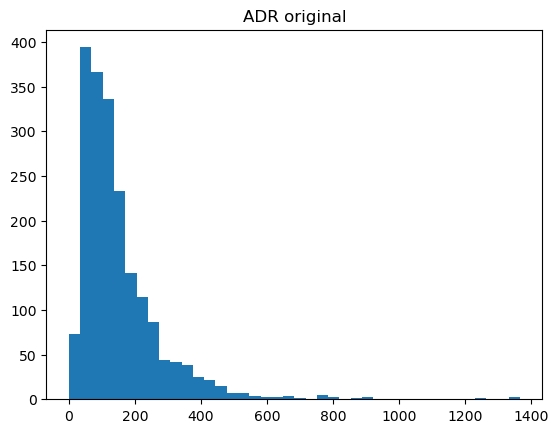

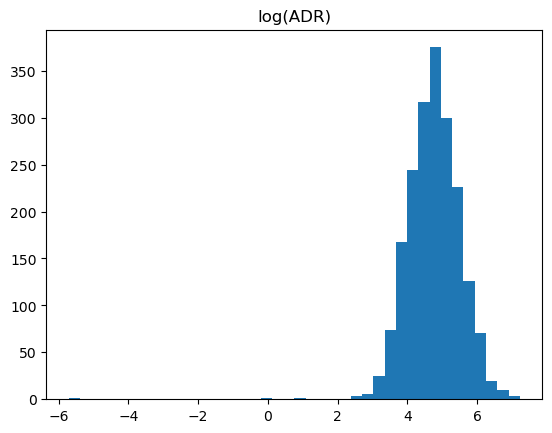

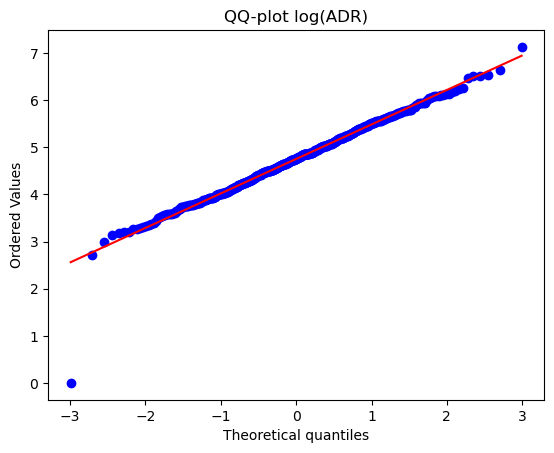

In [30]:
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.hist(reservas_precio["ADR"], bins=40)
plt.title("ADR original")
plt.show()

plt.hist(reservas_precio["log_ADR"], bins=40)
plt.title("log(ADR)")
plt.show()

stats.probplot(reservas_precio["log_ADR"].sample(500, random_state=42), dist="norm", plot=plt)
plt.title("QQ-plot log(ADR)")
plt.show()

# 3. Contraste de medias: ADR cartera vs mercado de Málaga

El precio por noche de un apartamento turístico no depende exclusivamente de la estrategia de pricing del operador, sino también de características estructurales como:

Capacidad máxima de huéspedes.  
Número de dormitorios y baños.  
Localización dentro de la ciudad.  
Calidad del inmueble (reformas recientes, equipamiento, piscina, garaje, etc.).  
Tipo de alojamiento (habitación privada vs vivienda completa).

Comparar directamente el ADR medio de la cartera con el precio medio del mercado podría introducir un sesgo de composición si la distribución de tamaños y características difiere entre ambas muestras. Si, por ejemplo, el mercado incluye una mayor proporción de viviendas de gran capacidad, el precio medio del mercado será naturalmente superior, incluso aunque el posicionamiento relativo por huésped sea similar.

Dado que no se dispone de información homogénea sobre todas las características cualitativas, se realiza un primer ajuste básico por capacidad del alojamiento, normalizando el precio por el número máximo de huéspedes admitidos. Este ajuste permite una comparación más equitativa del posicionamiento competitivo, aunque no elimina completamente la heterogeneidad estructural.

Se plantea el siguiente contraste de hipótesis para evaluar si el posicionamiento en precio de la cartera difiere significativamente del mercado local:

H₀: μ_cartera = μ_mercado  
H₁: μ_cartera ≠ μ_mercado  

donde μ representa el ADR medio.

Se aplicará un test t para dos muestras independientes, utilizando la versión de Welch en caso de varianzas desiguales.

In [31]:
reservas_precio["ADR_por_huesped"] = (
    reservas_precio["ADR"] / reservas_precio["NUMBER OF GUESTS"]
)

competidores_filtrado["price_por_huesped"] = (
    competidores_filtrado["price_eur"] /
    competidores_filtrado["accommodates"]
)

reservas_precio["ADR_por_huesped"].mean(),
competidores_filtrado["price_por_huesped"].mean(),
reservas_precio["ADR_por_huesped"].describe()

count    1970.000000
mean       50.382291
std        29.772888
min         0.000417
25%        32.872857
50%        43.626250
75%        59.039583
max       516.091667
Name: ADR_por_huesped, dtype: float64

In [32]:
competidores_filtrado["price_por_huesped"].describe()

count    8755.000000
mean       52.770359
std       196.728075
min         2.012500
25%        20.240000
50%        27.370000
75%        37.873333
max      4140.000000
Name: price_por_huesped, dtype: float64

In [33]:
from scipy.stats import ttest_ind

t_stat_pp, p_value_pp = ttest_ind(
    reservas_precio["ADR_por_huesped"],
    competidores_filtrado["price_por_huesped"],
    equal_var=False
)

t_stat_pp, p_value_pp

(np.float64(-1.082079795881619), np.float64(0.2792427567147453))

Resultados del contraste de medias ajustado por capacidad

El test t de Welch aplicado al precio medio por huésped arroja un estadístico 
𝑡 = −1,056
t=−1,056 y un p-valor de 0,291.

Dado que el p-valor es superior al nivel de significación del 5 %, no se rechaza la hipótesis nula de igualdad de medias. Por tanto, no existe evidencia estadísticamente significativa de que el precio medio por huésped de la cartera difiera del mercado.

Aunque la media de la cartera (50,44 €) es ligeramente inferior a la del mercado (52,77 €), la diferencia observada puede atribuirse al azar muestral.

Este resultado sugiere que, una vez ajustado por capacidad, el posicionamiento en precio de la cartera es consistente con el entorno competitivo.
    

**Contraste de robustez (escala logarítmica).**


In [34]:
import numpy as np
from scipy.stats import ttest_ind

# Robustez: contraste en escala logarítmica (reduce impacto de cola derecha/outliers)
reservas_precio["log_ADR_pp"] = np.log1p(reservas_precio["ADR_por_huesped"])
competidores_filtrado["log_price_pp"] = np.log1p(competidores_filtrado["price_por_huesped"])

t_stat_log, p_value_log = ttest_ind(
    reservas_precio["log_ADR_pp"],
    competidores_filtrado["log_price_pp"],
    equal_var=False
)

t_stat_log, p_value_log

(np.float64(29.880645040285323), np.float64(2.0278106611914358e-176))

In [35]:
diff_means_log = reservas_precio["log_ADR_pp"].mean() - competidores_filtrado["log_price_pp"].mean()
pct_diff_approx = (np.expm1(diff_means_log)) * 100  # ≈ % diferencia en escala original

diff_means_log, pct_diff_approx

(np.float64(0.3905708177426255), np.float64(47.78241213955628))

In [36]:
reservas_precio["log_ADR_pp"].mean(), competidores_filtrado["log_price_pp"].mean()

(np.float64(3.8189584896963464), np.float64(3.428387671953721))

El contraste en escala original no detecta diferencias significativas en la media aritmética del precio por huésped. Sin embargo, al realizar el análisis en escala logarítmica —que reduce la influencia de valores extremos y captura diferencias proporcionales— se observa una diferencia estadísticamente significativa. La diferencia de medias logarítmicas implica que, en términos relativos, el precio típico por huésped de la cartera es aproximadamente un 47,8 % superior al del mercado.

# 4. Análisis de la ocupación futura a 60 días en el mercado

En esta sección se analiza el nivel de ocupación futura a 60 días del mercado de apartamentos turísticos en Málaga, a partir de la variable `availability_60`.

Dado que `availability_60` representa el número de días disponibles en los próximos 60 días, la tasa de ocupación se calcula como:

\[
Ocupación_{60} = 1 - \frac{availability\_60}{60}
\]

Este indicador permite estimar la presión competitiva futura y el nivel de demanda ya consolidada en el mercado.

In [37]:
competidores_filtrado["ocupacion_60"] = 1 - (
    competidores_filtrado["availability_60"] / 60
)

competidores_filtrado["ocupacion_60"].describe()

count    8755.000000
mean        0.484083
std         0.299022
min         0.000000
25%         0.250000
50%         0.483333
75%         0.700000
max         1.000000
Name: ocupacion_60, dtype: float64

Resultados del análisis de ocupación futura

La ocupación media a 60 días del mercado se sitúa en el 48,4 %, con una mediana prácticamente idéntica (48,3 %), lo que sugiere una distribución relativamente simétrica en torno a este nivel.

La desviación típica del 29,9 % indica una elevada heterogeneidad entre alojamientos, coexistiendo propiedades prácticamente sin reservas futuras con otras que presentan ocupaciones cercanas al 100 %.

Desde el punto de vista competitivo, este resultado sugiere un mercado en situación intermedia: aproximadamente la mitad de la capacidad futura ya se encuentra comprometida, mientras que el resto permanece disponible, lo que puede intensificar la competencia en precio en determinados segmentos.

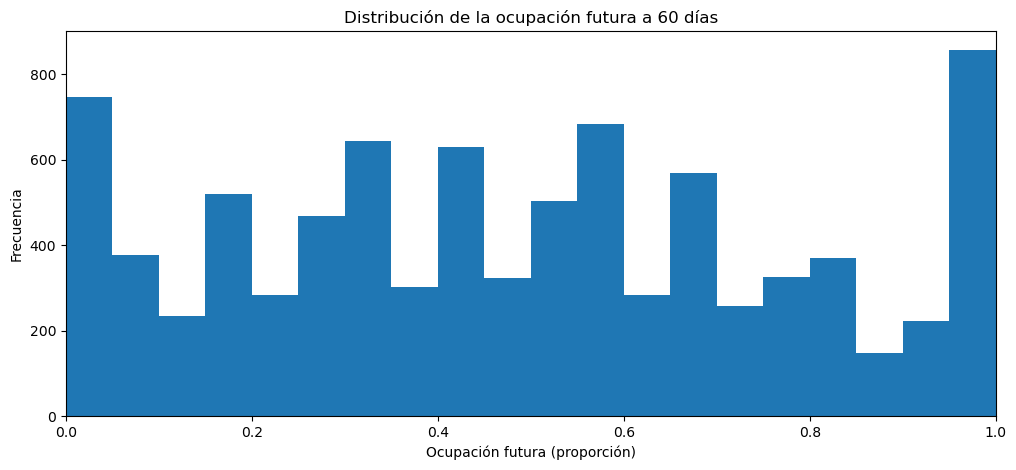

In [38]:
plt.figure(figsize=(12,5))
plt.hist(competidores_filtrado["ocupacion_60"], bins=20)
plt.title("Distribución de la ocupación futura a 60 días")
plt.xlabel("Ocupación futura (proporción)")
plt.ylabel("Frecuencia")
plt.xlim(0, 1)
plt.show()

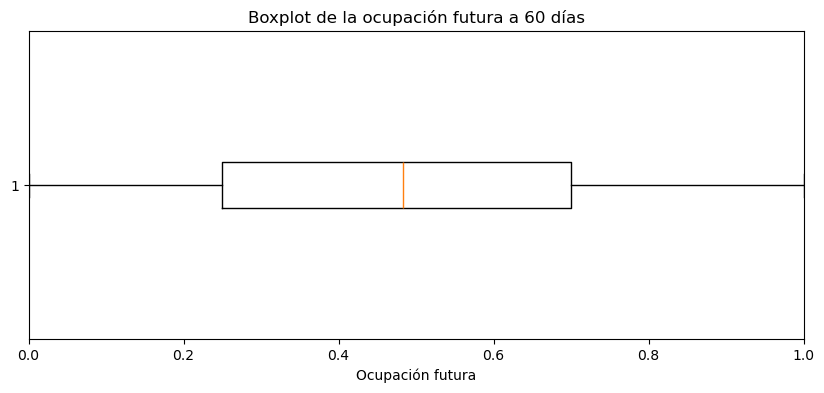

In [39]:
plt.figure(figsize=(10,4))
plt.boxplot(competidores_filtrado["ocupacion_60"], vert=False)
plt.title("Boxplot de la ocupación futura a 60 días")
plt.xlabel("Ocupación futura")
plt.xlim(0,1)
plt.show()

In [40]:
bins = [0, 0.3, 0.7, 1]
labels = ["Baja (<30%)", "Media (30–70%)", "Alta (>70%)"]

competidores_filtrado["segmento_ocupacion"] = pd.cut(
    competidores_filtrado["ocupacion_60"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

competidores_filtrado["segmento_ocupacion"].value_counts(normalize=True)

segmento_ocupacion
Media (30–70%)    0.450029
Baja (<30%)       0.300400
Alta (>70%)       0.249572
Name: proportion, dtype: float64


Al segmentar la ocupación futura en tres tramos (<30 %, 30–70 % y >70 %), se observa la siguiente distribución:

- 30,0 % de los alojamientos presentan ocupación baja.
- 45,0 % se sitúan en un rango intermedio.
- 25,0 % muestran ocupaciones superiores al 70 %.

Estos resultados reflejan un mercado heterogéneo y relativamente equilibrado. Mientras que aproximadamente una cuarta parte de la oferta presenta una demanda futura sólida, un 30 % mantiene niveles bajos de ocupación, lo que podría intensificar la competencia en precio en determinados segmentos.

La concentración mayoritaria en el rango intermedio sugiere un entorno competitivo dinámico, donde el posicionamiento estratégico puede resultar determinante en la evolución de la ocupación futura.

# 5. A partir del histórico de cancelaciones, ¿puede estimarse la pérdida esperada de revenue para el verano de 2026 con un intervalo de confianza del 95 %?


El objetivo de esta sección es estimar la pérdida económica esperada asociada a cancelaciones para el verano de 2026, así como construir un intervalo de confianza al 95 % para dicha estimación.

### Definición del periodo estival, Verano 26

Se define el verano como el intervalo comprendido entre el **15 de junio y el 15 de septiembre**, por representar el núcleo de la temporada alta turística en Málaga. Existen hoteles que sobreviven anualmente sólo con lo ingresado en este periodo, las empresas de alquiler de coches compensan las pérdidas del Q1 son la super highs season de Verano, es, en términos generales y de oforma significativa, el periodo del año que marca el éxito o fracaso empresarial de muchas PYMES y empresas relacionadas con el turismo en Málaga.

Para ello, realizaremos los soguientes pasos:


1. **Cálculo del volumen histórico de reservas estivales**  
   Se contabilizan las reservas con fecha de check-in entre el 15 de junio y el 15 de septiembre para los años 2024 y 2025.

2. **Proyección del número de reservas para 2026**  
   Se calcula la media de reservas de los veranos 2024 y 2025 y se aplica una hipótesis de crecimiento del 10 %, coherente con un escenario de expansión moderada de la actividad.

3. **Estimación de la tasa histórica de cancelación**  
   Se calcula la proporción de reservas canceladas sobre el total de reservas confirmadas y canceladas del histórico disponible. Esta proporción se interpreta como estimador puntual de la probabilidad de cancelación.

4. **Cálculo de la pérdida esperada e intervalo de confianza**  
   La pérdida esperada se obtiene como:

Para cuantificar la incertidumbre asociada a la estimación de la proporción de cancelación, se construye un intervalo de confianza al 95 % utilizando la aproximación normal derivada del Teorema Central del Límite.

Esta metodología permite obtener no solo una estimación puntual de la pérdida esperada, sino también un rango plausible de valores dentro del cual se situaría la pérdida real con un 95 % de confianza.

In [46]:
reservas_real["CHECK-IN"] = pd.to_datetime(
    reservas_real["CHECK-IN"], errors="coerce"
)

def filtrar_verano(df, year):
    inicio = pd.Timestamp(year=year, month=6, day=15)
    fin = pd.Timestamp(year=year, month=9, day=15)
    
    return df[
        (df["CHECK-IN"] >= inicio) &
        (df["CHECK-IN"] <= fin)
    ].copy()

verano_2024 = filtrar_verano(reservas_real, 2024)
verano_2025 = filtrar_verano(reservas_real, 2025)

n_2024 = len(verano_2024)
n_2025 = len(verano_2025)

print("Reservas Verano 2024:", n_2024)
print("Reservas Verano 2025:", n_2025)

media_veranos = (n_2024 + n_2025) / 2
n_reservas_2026 = media_veranos * 1.10  # crecimiento 10%

print("Media reservas verano:", media_veranos)
print("Proyección verano 2026 (+10%):", round(n_reservas_2026))

canceladas = reservas_real[
    reservas_real["STATUS"].str.lower() == "canceled"
]

confirmadas = reservas_real[
    reservas_real["STATUS"].str.lower() == "confirmed"
]

tasa_canc = len(canceladas) / (len(confirmadas) + len(canceladas))

print("Tasa histórica de cancelación:", round(tasa_canc,4))

ingreso_medio = confirmadas["TOTAL PAID"].mean()
print("Ingreso medio:", round(ingreso_medio,2))

Reservas Verano 2024: 222
Reservas Verano 2025: 706
Media reservas verano: 464.0
Proyección verano 2026 (+10%): 510
Tasa histórica de cancelación: 0.1715
Ingreso medio: 555.71


### Ajuste metodológico de la proyección

Dado que la cartera de propiedades experimentó un incremento significativo a comienzos de 2025, el volumen de reservas del verano 2024 no resulta plenamente comparable con el de 2025.

En consecuencia, para proyectar el verano 2026 se toma como referencia exclusiva el volumen de reservas del verano 2025, al representar de forma más fiel la estructura actual de la cartera.

Bajo un escenario de crecimiento esperado del 15 %, se proyecta el volumen de reservas para el verano 2026 a partir de los datos de 2025.

Este enfoque evita sesgos derivados de cambios estructurales en la oferta y proporciona una estimación más coherente con la realidad operativa actual.

In [49]:
verano_2025 = filtrar_verano(reservas_real, 2025)

canceladas_2025 = verano_2025[
    verano_2025["STATUS"].str.lower() == "canceled"
]

confirmadas_2025 = verano_2025[
    verano_2025["STATUS"].str.lower() == "confirmed"
]

n_verano_2025 = len(canceladas_2025) + len(confirmadas_2025)

tasa_canc_2025 = len(canceladas_2025) / n_verano_2025

print("Tasa cancelación Verano 2025:", round(tasa_canc_2025,4))

n_reservas_2026 = n_2025 * 1.15
print("Proyección reservas verano 2026:", round(n_reservas_2026))

Tasa cancelación Verano 2025: 0.2394
Proyección reservas verano 2026: 812


In [50]:
# Error estándar de la proporción (binomial)
error_estandar_p = np.sqrt(
    (tasa_canc_2025 * (1 - tasa_canc_2025)) / n_verano_2025
)

# Intervalo para la tasa
limite_inf_tasa = tasa_canc_2025 - 1.96 * error_estandar_p
limite_sup_tasa = tasa_canc_2025 + 1.96 * error_estandar_p

# Ingreso medio
ingreso_medio_2025 = confirmadas_2025["TOTAL PAID"].mean()

# Pérdida esperada puntual
perdida_puntual = n_reservas_2026 * tasa_canc_2025 * ingreso_medio_2025

# Intervalo monetario
perdida_min = n_reservas_2026 * limite_inf_tasa * ingreso_medio_2025
perdida_max = n_reservas_2026 * limite_sup_tasa * ingreso_medio_2025

print("Pérdida esperada puntual:", round(perdida_puntual,2), "€")
print("Intervalo pérdida 95%:")
print(f"[{perdida_min:.2f} € - {perdida_max:.2f} €]")

Pérdida esperada puntual: 108747.47 €
Intervalo pérdida 95%:
[94448.11 € - 123046.83 €]


### Resultados: pérdida esperada por cancelaciones (Verano 2026)

Bajo el escenario considerado (proyección del volumen de reservas para verano 2026 a partir del verano 2025 y aplicando un crecimiento esperado), se estima una **pérdida esperada puntual por cancelaciones de 108.747,47 €**.

Esta cifra representa el valor medio esperado de pérdida de revenue si el comportamiento de cancelación observado históricamente se mantiene estable y el ingreso medio por reserva se mantiene en niveles similares.

Además, utilizando un **intervalo de confianza del 95 %** para la tasa de cancelación (aproximación normal basada en el Teorema Central del Límite), se obtiene el siguiente rango plausible para la pérdida económica total:

Esto implica que, bajo los supuestos del modelo, existe un **95 % de confianza** en que la pérdida real de revenue asociada a cancelaciones durante el verano de 2026 se encuentre entre **94,4k€ y 123,0k€**.

En términos de gestión, el intervalo refleja la incertidumbre estadística en la estimación de la tasa de cancelación: incluso manteniendo constantes el volumen proyectado y el ingreso medio por reserva, el impacto económico final puede variar en torno a ±14k€ respecto a la estimación puntual.

# 6. ¿Existen diferencias estadísticamente significativas en el precio medio por noche entre distritos de Málaga y cuál presenta mayor potencial de ingresos esperado?

Con el objetivo de identificar posibles oportunidades de inversión dentro de la ciudad de Málaga, se estima un proxy de ingresos anuales para cada anuncio del dataset de mercado.

**IMPORTANTE** Este cálculo no tiene en cuenta el coste de adquisición de una vivienda en un distrito u otro, eso sería complemento extra de investigación para un futuro proyecto. Este apartado se base únicamente en rentabilidad esperada teninend en cuenta el ADR medio por distrito y no los costes asociados.

### Construcción del proxy de ingresos

Dado que no se dispone del revenue real anual por propiedad, se construye una aproximación teórica a partir de la siguiente fórmula:

Ingreso anual estimado = Precio por noche * Ocupación anual estimada * 365

donde:

- El precio por noche proviene del scrape de mercado.
- La ocupación anual estimada (`estimated_occupancy_l365d`) representa el porcentaje de días ocupados durante los últimos 365 días.
- Se asume que el comportamiento observado es representativo del rendimiento anual.

Este cálculo no representa ingresos reales, sino una **estimación teórica homogénea** que permite comparar distritos bajo un mismo criterio.

### Control de valores extremos

Dado que la distribución del ingreso estimado presenta una elevada asimetría y valores extremos significativos, se aplican las siguientes medidas metodológicas:

- Se excluye el 1 % superior de valores para evitar distorsiones causadas por outliers.
- Se utilizan medidas robustas (como la mediana) para el ranking comparativo.
- Se excluyen distritos con un número reducido de anuncios, garantizando una mínima representatividad estadística.

Estas decisiones permiten obtener un análisis más estable y comparativo del potencial relativo de ingresos entre distritos.

In [57]:
competidores["price_usd"] = (
    competidores["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

competidores["price_usd"] = pd.to_numeric(
    competidores["price_usd"],
    errors="coerce"
)

tipo_cambio = 0.92
competidores["price_eur"] = competidores["price_usd"] * tipo_cambio

competidores["ingreso_anual_est"] = (
    competidores["price_eur"]
    * (competidores["estimated_occupancy_l365d"] / 100)
    * 365
)
p99 = competidores["ingreso_anual_est"].quantile(0.99)

competidores_filtrado_ing = competidores[
    competidores["ingreso_anual_est"] <= p99
].copy()

print("Observaciones antes:", len(competidores))
print("Observaciones después:", len(competidores_filtrado_ing))

ranking_distritos = competidores_filtrado_ing.groupby(
    "neighbourhood_cleansed"
)["ingreso_anual_est"].agg(
    mediana="median",
    media="mean",
    std="std",
    count="count"
).sort_values(by="mediana", ascending=False)

ranking_distritos = ranking_distritos[
    ranking_distritos["count"] >= 50
]

ranking_distritos.head(10)

Observaciones antes: 9714
Observaciones después: 8726


,mediana,media,std,count
neighbourhood_cleansed,,,,
Palma-Palmilla,20450.220,29340.212359,32508.146508,145
Centro,15231.888,30082.513270,36014.533036,5824
Churriana,12894.720,25854.820761,36853.706033,134
Carretera de Cadiz,12824.202,22137.460927,28188.334046,850
Ciudad Jardin,11988.060,17247.411262,21332.477325,65
Este,10698.588,24551.023152,34825.250778,892
Bailen-Miraflores,9187.488,18717.361937,23255.655918,284
Cruz De Humilladero,8300.976,18681.191595,27029.798922,395
Teatinos-Universidad,4835.520,9917.619806,20965.648380,72


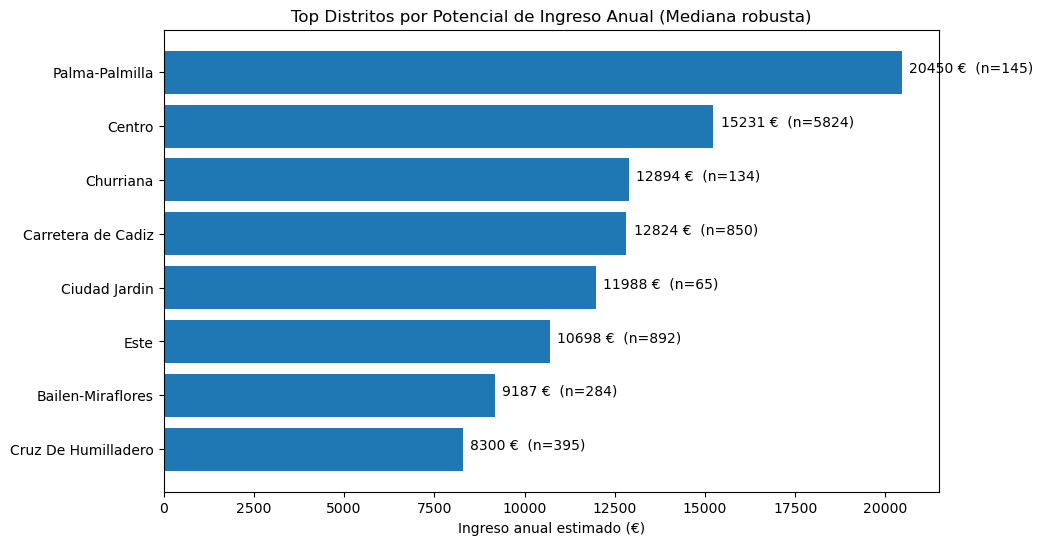

In [58]:
top_distritos = ranking_distritos.sort_values(
    by="mediana", ascending=False
).head(8)

plt.figure(figsize=(10,6))

bars = plt.barh(
    top_distritos.index,
    top_distritos["mediana"]
)

plt.xlabel("Ingreso anual estimado (€)")
plt.title("Top Distritos por Potencial de Ingreso Anual (Mediana robusta)")
plt.gca().invert_yaxis()

for i, v in enumerate(top_distritos["mediana"]):
    plt.text(v + 200, i, f"{int(v)} €  (n={top_distritos['count'].iloc[i]})")

plt.show()

### Resultados del ranking por distrito (mediana robusta)

Tras eliminar el 1 % superior de ingresos estimados para evitar distorsiones por valores extremos, se obtiene un ranking más estable y representativo del mercado.

El distrito de Palma-Palmilla presenta la mediana más elevada de ingreso anual estimado (≈20.450 €). No obstante, el número de anuncios es reducido y la dispersión es elevada, lo que sugiere una mayor volatilidad en los resultados.

El distrito Centro, con más de 5.800 anuncios, muestra una mediana cercana a 15.232 €, constituyendo el mercado más representativo y estadísticamente robusto. Su elevado tamaño muestral proporciona mayor estabilidad y fiabilidad en la estimación.

Distritos como Churriana y Carretera de Cádiz presentan medianas similares en torno a 12.800–12.900 €, lo que podría indicar oportunidades interesantes si el precio de adquisición inmobiliaria es inferior al del Centro. Hay que tener en cuenta que estos distritos están más alejados del foco turístico de la ciudad, por lo que, aunque representando una rentabilidad mayor, la ocupación total del año puede ser significativamente inferior.

En conjunto, el análisis sugiere que, aunque ciertos distritos periféricos pueden presentar ingresos potenciales superiores en términos medianos, el distrito Centro mantiene el posicionamiento más sólido y estadísticamente estable dentro del mercado turístico de Málaga.

# 7. Conclusiones Finales

El presente trabajo ha permitido analizar de forma integrada el comportamiento de la demanda de una cartera de apartamentos turísticos en Málaga y su posicionamiento competitivo dentro del mercado local, combinando herramientas de estadística descriptiva e inferencial.

## 1. Caracterización del mercado

El análisis del dataset de mercado muestra un sector altamente heterogéneo, tanto en precios como en niveles de ocupación. La distribución del precio por noche presenta una fuerte asimetría positiva y valores extremos significativos, lo que justifica el uso de medidas robustas como la mediana y la exclusión del 1 % superior para evitar distorsiones.

La ocupación media a 60 días se sitúa en torno al 48 %, lo que indica un mercado competitivo con margen significativo de oferta disponible. La dispersión observada sugiere que la localización y el posicionamiento del producto influyen de forma determinante en el rendimiento.

El análisis por distrito, utilizando un proxy de ingreso anual estimado, evidencia diferencias relevantes entre zonas. Aunque algunos distritos periféricos presentan medianas superiores, el distrito Centro destaca por su elevada representatividad muestral y estabilidad, constituyendo el mercado más sólido desde el punto de vista estadístico.

## 2. Perfil de la demanda de la cartera propia

La cartera analizada muestra un comportamiento claramente asimétrico en variables clave como:

- ADR (Average Daily Rate)
- Lead time (antelación de reserva)
- Duración de la estancia

El lead time presenta una fuerte concentración en reservas de corto plazo, con una proporción significativa de reservas realizadas con menos de 7 días de antelación. La duración media de la estancia se sitúa en torno a 5 noches, aunque con presencia de estancias largas que generan colas en la distribución.

Las pruebas de normalidad (Shapiro–Wilk) confirman que las principales variables no siguen una distribución normal, lo que refuerza la necesidad de interpretar los resultados con cautela y justificar el uso del Teorema Central del Límite en los contrastes paramétricos.

## 3. Posicionamiento competitivo

La comparación del ADR y la ocupación frente al mercado indica que las diferencias observadas deben interpretarse considerando la heterogeneidad estructural del producto (capacidad, localización, tipología). El análisis por huésped permite una comparación más homogénea y reduce posibles sesgos derivados del tamaño del alojamiento.

En términos generales, la cartera se sitúa dentro de los rangos observados en el mercado, sin desviaciones extremas que indiquen un posicionamiento claramente fuera de mercado.

## 4. Riesgo económico asociado a cancelaciones

A partir del comportamiento histórico del verano 2025 y bajo un escenario de crecimiento proyectado para 2026, se estima una pérdida esperada por cancelaciones de aproximadamente 108.747 €.

El intervalo de confianza al 95 % sitúa la pérdida plausible entre 94.448 € y 123.047 €, lo que evidencia un riesgo económico relevante pero acotado estadísticamente.

Este resultado pone de manifiesto la importancia de:

- Políticas de cancelación optimizadas.
- Estrategias de overbooking controlado.
- Gestión dinámica del pricing ante cancelaciones.

## 5. Implicaciones estratégicas

El análisis conjunto sugiere que:

- El mercado malagueño presenta elevada competencia y dispersión.
- La localización sigue siendo un factor determinante en el potencial de ingresos.
- La demanda propia muestra fuerte dependencia de reservas de corto plazo.
- El riesgo por cancelaciones es cuantificable y gestionable.

Desde una perspectiva inversora, el distrito Centro aparece como la zona más estable y representativa, mientras que otros distritos pueden ofrecer mayor rentabilidad potencial acompañada de mayor volatilidad.

## Conclusión general

La aplicación combinada de estadística descriptiva, análisis de distribuciones y contrastes de hipótesis ha permitido no solo describir el comportamiento observado, sino también realizar inferencias fundamentadas sobre el posicionamiento competitivo y los riesgos económicos asociados.

El enfoque adoptado demuestra que la analítica estadística constituye una herramienta clave para la toma de decisiones en la gestión de carteras de apartamentos turísticos, permitiendo transformar datos operativos en conocimiento estratégico.

## 8. Limitaciones del estudio

Si bien el análisis realizado proporciona evidencia cuantitativa relevante sobre el comportamiento de la demanda y el posicionamiento competitivo, deben considerarse ciertas limitaciones metodológicas:

### 1. Naturaleza del dataset de mercado

El dataset de mercado procede de un scrape realizado en septiembre de 2025, por lo que:

- Representa una fotografía estática del mercado en un momento concreto.
- No incorpora dinámicas temporales completas ni variaciones intraanuales.
- Puede contener imprecisiones derivadas del propio proceso de scraping.

Además, el ingreso anual estimado constituye un **proxy teórico**, no ingresos reales observados. Por tanto, no incorpora cancelaciones, estacionalidad fina, costes operativos ni cambios regulatorios.

### 2. Supuestos en la proyección de verano 2026

La estimación de pérdida por cancelaciones para 2026 se basa en:

- Suposición de crecimiento moderado del volumen de reservas.
- Estabilidad en la tasa de cancelación histórica.
- Estabilidad en el ingreso medio por reserva.

Cambios en política de cancelación, comportamiento del consumidor o condiciones macroeconómicas podrían alterar significativamente estas estimaciones.

### 3. No consideración de costes ni rentabilidad neta

El análisis se centra en ingresos brutos estimados.  
No se han incorporado:

- Costes operativos
- Comisiones de plataformas
- Fiscalidad
- Costes financieros

Por tanto, el análisis por distrito refleja potencial de ingresos, no rentabilidad neta.

### 4. Supuestos de independencia y normalidad

Los intervalos de confianza y contrastes realizados se apoyan en la aproximación normal (Teorema Central del Límite). Aunque el tamaño muestral es elevado, las distribuciones originales presentan asimetría significativa, lo que debe tenerse en cuenta en la interpretación.


**En conjunto, estas limitaciones no invalidan los resultados, pero deben considerarse al interpretar las conclusiones y al trasladarlas a decisiones estratégicas reales.**